In [3]:
import io
import sqlite3
from sqlite3 import Error
import ijson
import datetime

import numpy as np
import pandas as pd
import matplotlib

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

global db_conn
global json_data
global db_path
global df

In [4]:
from bin.util import DatabaseAdapter
import psycopg2
import pandas

db = DatabaseAdapter.Database("")
db_path = "..\\database\\CellPhonesAndAccessoriesDB.db"
#db_conn = sqlite3.connect(db_path)

table_name = "everything"

try:
    #db_conn = sqlite3.connect(db_path)

    #df = pd.read_sql_query("SELECT * FROM CellPhonesAndAccessoriesData", db_conn)
    df = db.retrieve_dataframe(table_name, 100000, "reviewText, class, overall")
    print(df.head())
except Error as e:
    print(e)

C:\Users\Pascal\PycharmProjects\amazon-spam-detection\bin\util\DatabaseAdapter.py:230: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataframe = pd.read_sql_query(


                                          reviewtext  class  overall
0  This thing HUGE! It larger than the stovetop b...    0.0      3.0
1  i live in the hills. cell reception is very sp...    1.0      4.0
2  its ok for the amature but the nuts that the a...    0.0      3.0
3  Ive had this keyboard for 2 months now and no ...    1.0      5.0
4  Great for the beginning golfer! My daughter lo...    1.0      5.0


<AxesSubplot: ylabel='Frequency'>

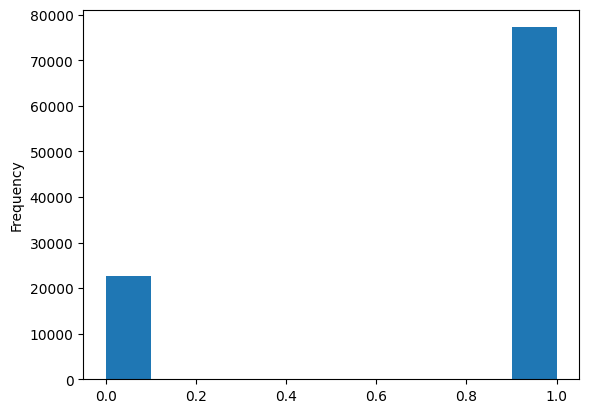

In [5]:
# observe review text length
def getTextLength(text: str) -> int:
    return len(text)
df['textlength'] = df['reviewtext'].apply(getTextLength)
df.head()
#Occurance no spam and spam
df["class"].plot.hist()

<AxesSubplot: >

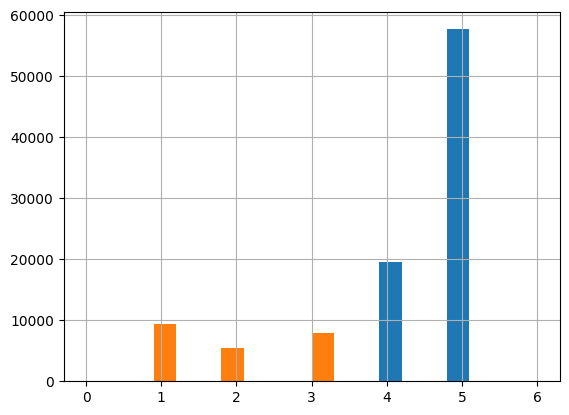

In [6]:
df_spam = df.loc[df['class'] == 1.0]
df_noSpam = df.loc[df['class'] == 0]

#df_spam['textlength'].hist( bins=20, range=[0, 1000])
#df_noSpam['textlength'].plot.hist(bins=20, range=[0, 1000])

df_spam['overall'].hist( bins=20, range=[0, 6])
df_noSpam['overall'].hist( bins=20, range=[0, 6])
#df_noSpam['class'].hist()
#df_spam['class'].hist()

In [7]:
print(f'mean textLength spam ' + str(df_spam['textlength'].mean()))
print(f'mean textLength no spam ' + str(df_noSpam['textlength'].mean()))

mean textLength spam 358.5020128147045
mean textLength no spam 401.8766761925698


In [8]:
#Multinomyal Naive Bias Model
x = df['reviewtext']
y = df['class']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3, random_state=53)

count_vectorizer = CountVectorizer(stop_words='english')
count_train = count_vectorizer.fit_transform(x_train.values)
count_test = count_vectorizer.transform(x_test.values)

nb_classifier = MultinomialNB()
nb_classifier.fit(count_train, y_train)

pred = nb_classifier.predict(count_test)


score = metrics.accuracy_score(y_test, pred)
print(f'Score {score}')

Score 0.8537666666666667


In [9]:
#preprocessing for filling the df
count_df = count_vectorizer.transform(x)
prob = nb_classifier.predict_proba(count_df)
pred_df =nb_classifier.predict(count_df)

print(f'prediction {pred_df}')
print(prob)

#fill df with probability and prediction values of each review text
df["predclass"] = 0
df['predclass'].iloc[0:len(pred_df)] = pred_df

df["prob0"] = 0
df['prob0'].iloc[0:len(prob)] = prob[:,0]

df["prob1"] = 1 #rundet die Werte
df['prob1'].iloc[0:len(prob)] = prob[:,1]
print(df)

prediction [0. 1. 0. ... 1. 1. 1.]
[[6.26625267e-01 3.73374733e-01]
 [3.47826307e-03 9.96521737e-01]
 [9.81819148e-01 1.81808518e-02]
 ...
 [2.51709001e-02 9.74829100e-01]
 [9.56548751e-05 9.99904345e-01]
 [9.48321316e-04 9.99051679e-01]]
                                              reviewtext  class  overall  \
0      This thing HUGE! It larger than the stovetop b...    0.0      3.0   
1      i live in the hills. cell reception is very sp...    1.0      4.0   
2      its ok for the amature but the nuts that the a...    0.0      3.0   
3      Ive had this keyboard for 2 months now and no ...    1.0      5.0   
4      Great for the beginning golfer! My daughter lo...    1.0      5.0   
...                                                  ...    ...      ...   
99995  My Grandaughter is going to Love it. Was very ...    1.0      5.0   
99996  We already owned Riedel wine glasses and got t...    1.0      5.0   
99997                    Great dagger. I really like it.    1.0      5.0   
9

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_17488\4122125783.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predclass'].iloc[0:len(pred_df)] = pred_df
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_17488\4122125783.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['prob0'].iloc[0:len(prob)] = prob[:,0]
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_17488\4122125783.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin